# Base de dados Apple Inc. (AAPL)

Dados históricos de preços (abertura, fechamento, alta, baixa, volume) para diversas ações da Apple Inc.

* Close	 ->  Preço de fechamento  
* High	- >  Preço na  alta
* Low   ->  Preço  na baixa
* Open  -> Preço de abertura
* Volume - >  Volume de ações negociadas

# **1. Carregar e explorar os dados**

In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf


In [1]:
import yfinance as yf

# Baixar dados da Apple (2010-2023)
data = yf.download('AAPL', start='2023-01-01', end='2023-12-31')

/tmp/ipykernel_382/1088562036.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2023-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


In [2]:
# Visualizando os primeiros registros da base
print(data.head(10))

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.876755  128.604513  121.992536  127.995391  112117500
2023-01-04  124.144142  126.403812  122.886590  124.664847   89113600
2023-01-05  122.827621  125.529397  122.572186  124.900621   80962700
2023-01-06  127.346939  128.005188  122.699890  123.800252   87754700
2023-01-09  127.867661  131.070502  127.612225  128.182056   70790800
2023-01-10  128.437515  128.958220  125.873284  127.975756   63896200
2023-01-11  131.149078  131.168717  128.172215  128.948354   69458900
2023-01-12  131.070480  131.905565  129.135026  131.532239   71379600
2023-01-13  132.396805  132.554003  129.351176  129.714683   57809700
2023-01-17  133.556137  134.882454  131.777880  132.465602   63646600


In [3]:
import matplotlib.pyplot as plt

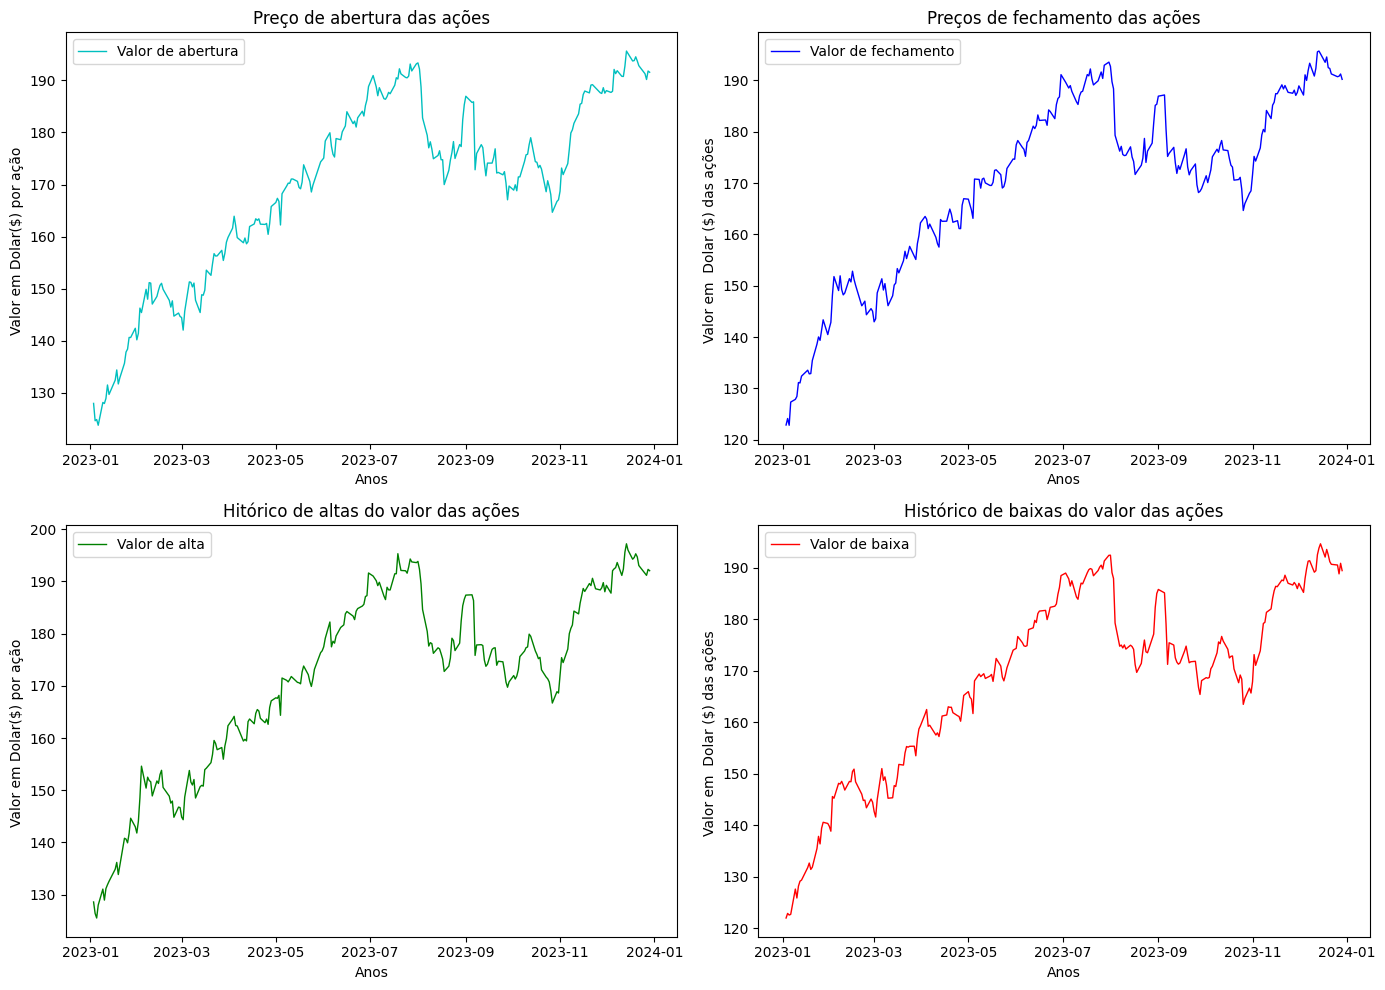

In [4]:
# Gráfico de dispersão para os targets
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

#Abertura
ax1.plot(data.index, data.Open, 'c-', linewidth=1, label='Valor de abertura')
ax1.set_xlabel('Anos')
ax1.set_ylabel('Valor em Dolar($) por ação ')
ax1.set_title('Preço de abertura das ações')
ax1.legend( loc ='best')

#Fechamento
ax2.plot(data.index, data.Close, 'b-', linewidth=1, label='Valor de fechamento')
ax2.set_xlabel('Anos')
ax2.set_ylabel('Valor em  Dolar ($) das ações ')
ax2.set_title('Preços de fechamento das ações')
ax2.legend(loc ='best')



#Alta
ax3.plot(data.index, data.High, 'g-', linewidth=1, label='Valor de alta')
ax3.set_xlabel('Anos')
ax3.set_ylabel('Valor em Dolar($) por ação ')
ax3.set_title('Hitórico de altas do valor das ações')
ax3.legend(loc ='best')
#Baixa
ax4.plot(data.index, data.Low, 'r-', linewidth=1, label='Valor de baixa')
ax4.set_xlabel('Anos')
ax4.set_ylabel('Valor em  Dolar ($) das ações ')
ax4.set_title('Histórico de baixas do valor das ações')
ax4.legend(loc='best')

plt.tight_layout()
plt.show()

## **Particionando a base  de dados**

* X_treinamento, y_treinamento
* X_teste, y_teste

In [48]:
nn_base_treinamento = int(len(data) * 0.8)
print(f"Treino: {nn_base_treinamento} | Teste: {len(data) - nn_base_treinamento}")

Treino: 200 | Teste: 50


In [49]:
base_treinamento = data.iloc[:nn_base_treinamento, 0:5].values

In [50]:
base_treinamento.shape

(200, 5)

## **Pré-processando os dados**

In [52]:
#Definindo o normalizador
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

In [53]:
#Normalizando a base de treinamento
base_treinamento_norm = scaler_X.fit_transform(base_treinamento)


In [54]:
#Normalizando a base de treinamento

y_treino_norm = scaler_y.fit_transform(base_treinamento[:, 0:1]).ravel()

## **Criando as janelas deslizantes**

In [55]:
#intervalo utilizado para relizar as previsões futuras é de 12 meses
intervalo_previsao = 12
X_treinamento, y_treinamento = [], []



In [56]:
for i in range(intervalo_previsao, nn_base_treinamento):
    X_treinamento.append(base_treinamento_norm[i - intervalo_previsao:i, 0:5])
    y_treinamento.append(y_treino_norm[i])

In [19]:
#Convertendo X e y de Listas para Arrays
X_treinamento = np.array(X_treinamento)
y_treinamento =np.array(y_treinamento)

In [57]:
X_treinamento = np.array(X_treinamento).reshape(-1, intervalo_previsao * 5)
y_treinamento = np.array(y_treinamento)

## **Construindo a base de teste (X_teste, y_teste)**

In [58]:
base_teste = data.iloc[nn_base_treinamento:, 0].values.reshape(-1, 1)


In [59]:
entradas = data.iloc[
    len(data) - len(base_teste) - intervalo_previsao:
].values


In [60]:
entradas_norm = scaler_X.transform(entradas)

In [61]:
X_teste, y_teste = [], []
nn_entradas = len(entradas)
for i in range(intervalo_previsao, nn_entradas):
    X_teste.append(entradas_norm[i - intervalo_previsao:i, 0:5])
    y_teste.append(entradas_norm[i, 0])

In [62]:
X_teste = np.array(X_teste).reshape(-1, intervalo_previsao * 5)


In [63]:
y_teste = np.array(y_teste).reshape(-1, 1)

## Criando a rede neural

In [64]:
from sklearn.neural_network import MLPRegressor

# Criar o modelo MLP
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 80,50,30,15,5),  # Duas camadas ocultas, a primeira com 100, e a segunda com  50 neuronios
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

In [67]:
# Treinar o modelo
#Treinamento do modelo mlp_regressor  com  X_treinamento_scaled, y_treinamento_scaled
history = mlp_regressor.fit(X_treinamento ,y_treinamento)


Iteration 1, loss = 0.64116581
Validation score: -32.736772
Iteration 2, loss = 0.57389010
Validation score: -29.842637
Iteration 3, loss = 0.52039708
Validation score: -27.258677
Iteration 4, loss = 0.47837693
Validation score: -25.596361
Iteration 5, loss = 0.45011366
Validation score: -24.151338
Iteration 6, loss = 0.42555369
Validation score: -22.795859
Iteration 7, loss = 0.40246006
Validation score: -21.378959
Iteration 8, loss = 0.37838231
Validation score: -19.911649
Iteration 9, loss = 0.35345616
Validation score: -18.195155
Iteration 10, loss = 0.32275330
Validation score: -16.528440
Iteration 11, loss = 0.29403587
Validation score: -15.047808
Iteration 12, loss = 0.26828282
Validation score: -13.496640
Iteration 13, loss = 0.24277137
Validation score: -12.181735
Iteration 14, loss = 0.22056124
Validation score: -11.034653
Iteration 15, loss = 0.20098865
Validation score: -9.951579
Iteration 16, loss = 0.18293925
Validation score: -8.951966
Iteration 17, loss = 0.16633719
Val

In [68]:
prev_norm = mlp_regressor.predict(X_teste).reshape(-1, 1)


In [69]:
prev_real = scaler_y.inverse_transform(prev_norm)


In [70]:
y_real = scaler_y.inverse_transform(y_teste)

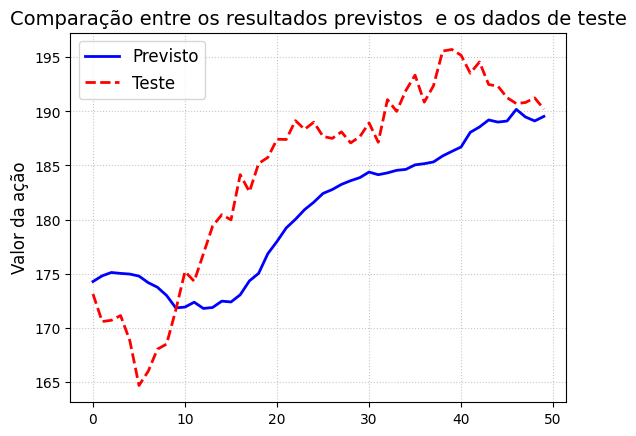

In [71]:
# Plotando as duas curvas

plt.plot( prev_real, 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_real, 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda



# Mostrando o gráfico
plt.show()

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_real, prev_real)
rmse = np.sqrt(mean_squared_error(y_real, prev_real))
mape = np.mean(np.abs((y_real - prev_real) / y_real)) * 100
print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}%")

MAE: 5.6922 | RMSE: 6.3534 | MAPE: 3.09%
